## EDA for credit card clients dataset
Goal: understand the dataset to build models to predict the probability of default (credit risks). EDA checks the quality of dataset, and data distribution that can affect model later.

# 1. Setup and upload data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

path = 'default of credit card clients.xls'

df = pd.read_excel(path, header=1)
print(df.shape)
df.head()

(30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


# 2. Data cleaning

In [2]:
# drop redundant column ID
df = df.drop(columns='ID')
# rename PAY_0 to PAY_1 for consistence 
df = df.rename(columns={'PAY_0': 'PAY_1'})

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   LIMIT_BAL                   30000 non-null  int64
 1   SEX                         30000 non-null  int64
 2   EDUCATION                   30000 non-null  int64
 3   MARRIAGE                    30000 non-null  int64
 4   AGE                         30000 non-null  int64
 5   PAY_1                       30000 non-null  int64
 6   PAY_2                       30000 non-null  int64
 7   PAY_3                       30000 non-null  int64
 8   PAY_4                       30000 non-null  int64
 9   PAY_5                       30000 non-null  int64
 10  PAY_6                       30000 non-null  int64
 11  BILL_AMT1                   30000 non-null  int64
 12  BILL_AMT2                   30000 non-null  int64
 13  BILL_AMT3                   30000 non-null  int64
 14  BILL_A

In [4]:
print(f'Check missing values: \n{df.isna().sum()}')
print(f'Check duplicate clients: \n{df.duplicated().sum()}')


Check missing values: 
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_1                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default payment next month    0
dtype: int64
Check duplicate clients: 
35


In [5]:
# Drop 35 duplicated rows
df = df.drop_duplicates()
# create a csv file from dataframe
df.to_csv('default credit.csv', index=False)

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
LIMIT_BAL,29965.0,167442.005006,129760.135222,10000.0,50000.0,140000.0,240000.0,1000000.0
SEX,29965.0,1.603738,0.489128,1.0,1.0,2.0,2.0,2.0
EDUCATION,29965.0,1.853629,0.790411,0.0,1.0,2.0,2.0,6.0
MARRIAGE,29965.0,1.551877,0.521997,0.0,1.0,2.0,2.0,3.0
AGE,29965.0,35.487969,9.219459,21.0,28.0,34.0,41.0,79.0
PAY_1,29965.0,-0.016753,1.123492,-2.0,-1.0,0.0,0.0,8.0
PAY_2,29965.0,-0.131854,1.196322,-2.0,-1.0,0.0,0.0,8.0
PAY_3,29965.0,-0.164392,1.195878,-2.0,-1.0,0.0,0.0,8.0
PAY_4,29965.0,-0.218922,1.168175,-2.0,-1.0,0.0,0.0,8.0
PAY_5,29965.0,-0.264509,1.132220,-2.0,-1.0,0.0,0.0,8.0


# 3. Correlation matrix

In [7]:
cat_features = ['SEX', 'EDUCATION', 'MARRIAGE', 'PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
con_features = ['AGE', 'LIMIT_BAL', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 
                  'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
target = 'default payment next month'

<Axes: >

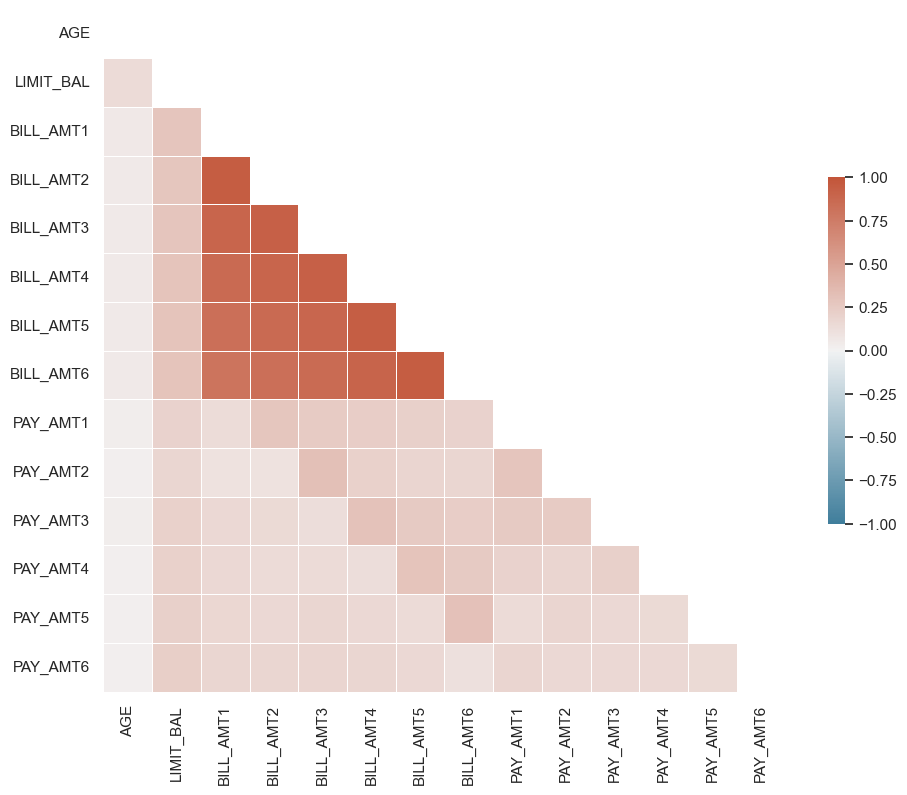

In [8]:
sns.set_theme(style="white")

# Compute the correlation matrix
corr = df[con_features].corr()

# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(11, 9))

# Generate a custom diverging colormap
cmap = sns.diverging_palette(230, 20, as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=1, vmin=-1, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})

# 4. Exploratory Information Visualization

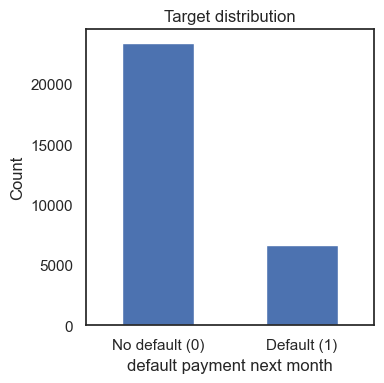

In [9]:

fig, ax = plt.subplots(figsize=(4, 4))
df[target].value_counts().sort_index().plot.bar(ax=ax)
ax.set_xticklabels(['No default (0)', 'Default (1)'], rotation=0)
ax.set_title('Target distribution')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

The dataset shows moderate class imbalance (22.1% default rate).

In [10]:
df['EDUCATION'] = df['EDUCATION'].replace({0: 4, 5: 4, 6: 4})  # collapse 0,5,6 into 4="others"
df['MARRIAGE'] = df['MARRIAGE'].replace({0: 3})  

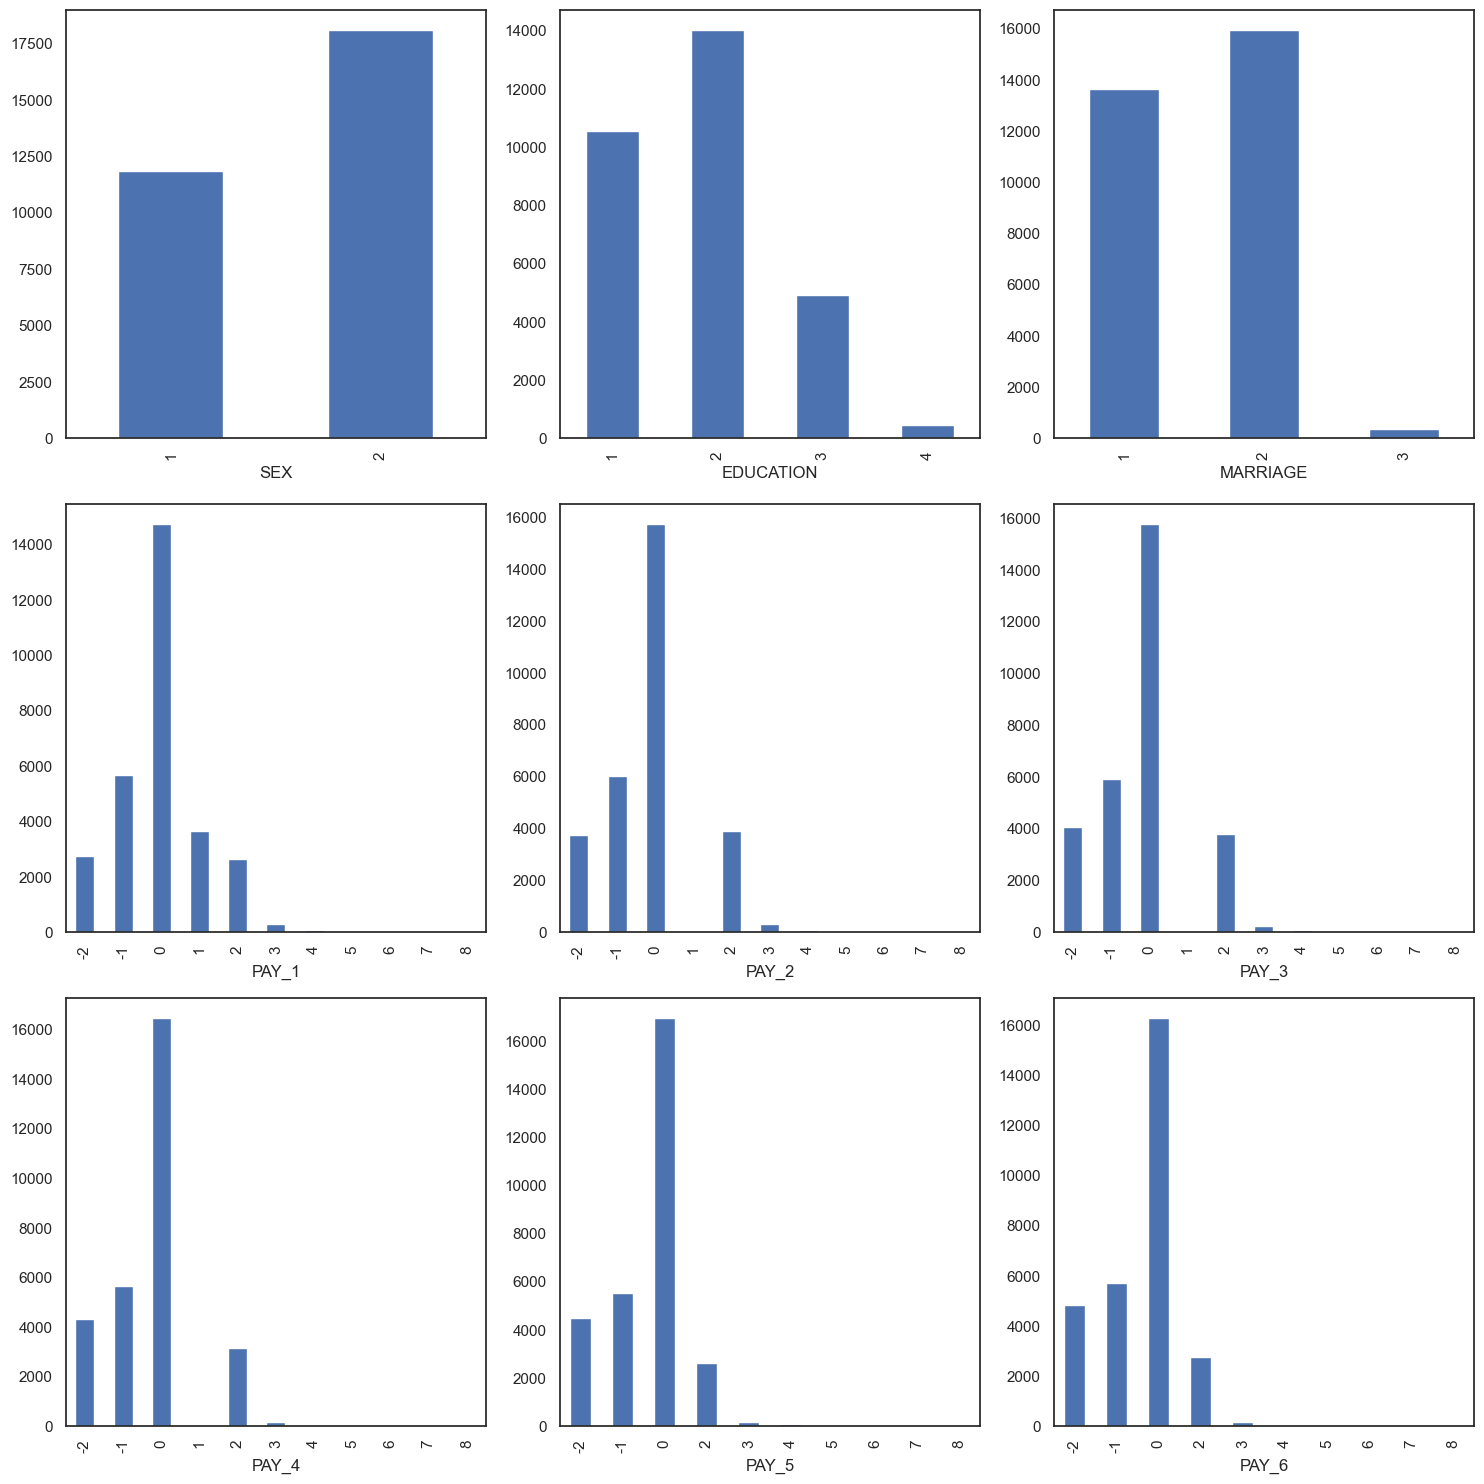

In [11]:
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
for ax, col in zip(axes.flatten(), cat_features):
    df[col].value_counts().sort_index().plot.bar(ax=ax)
plt.tight_layout()
plt.show()

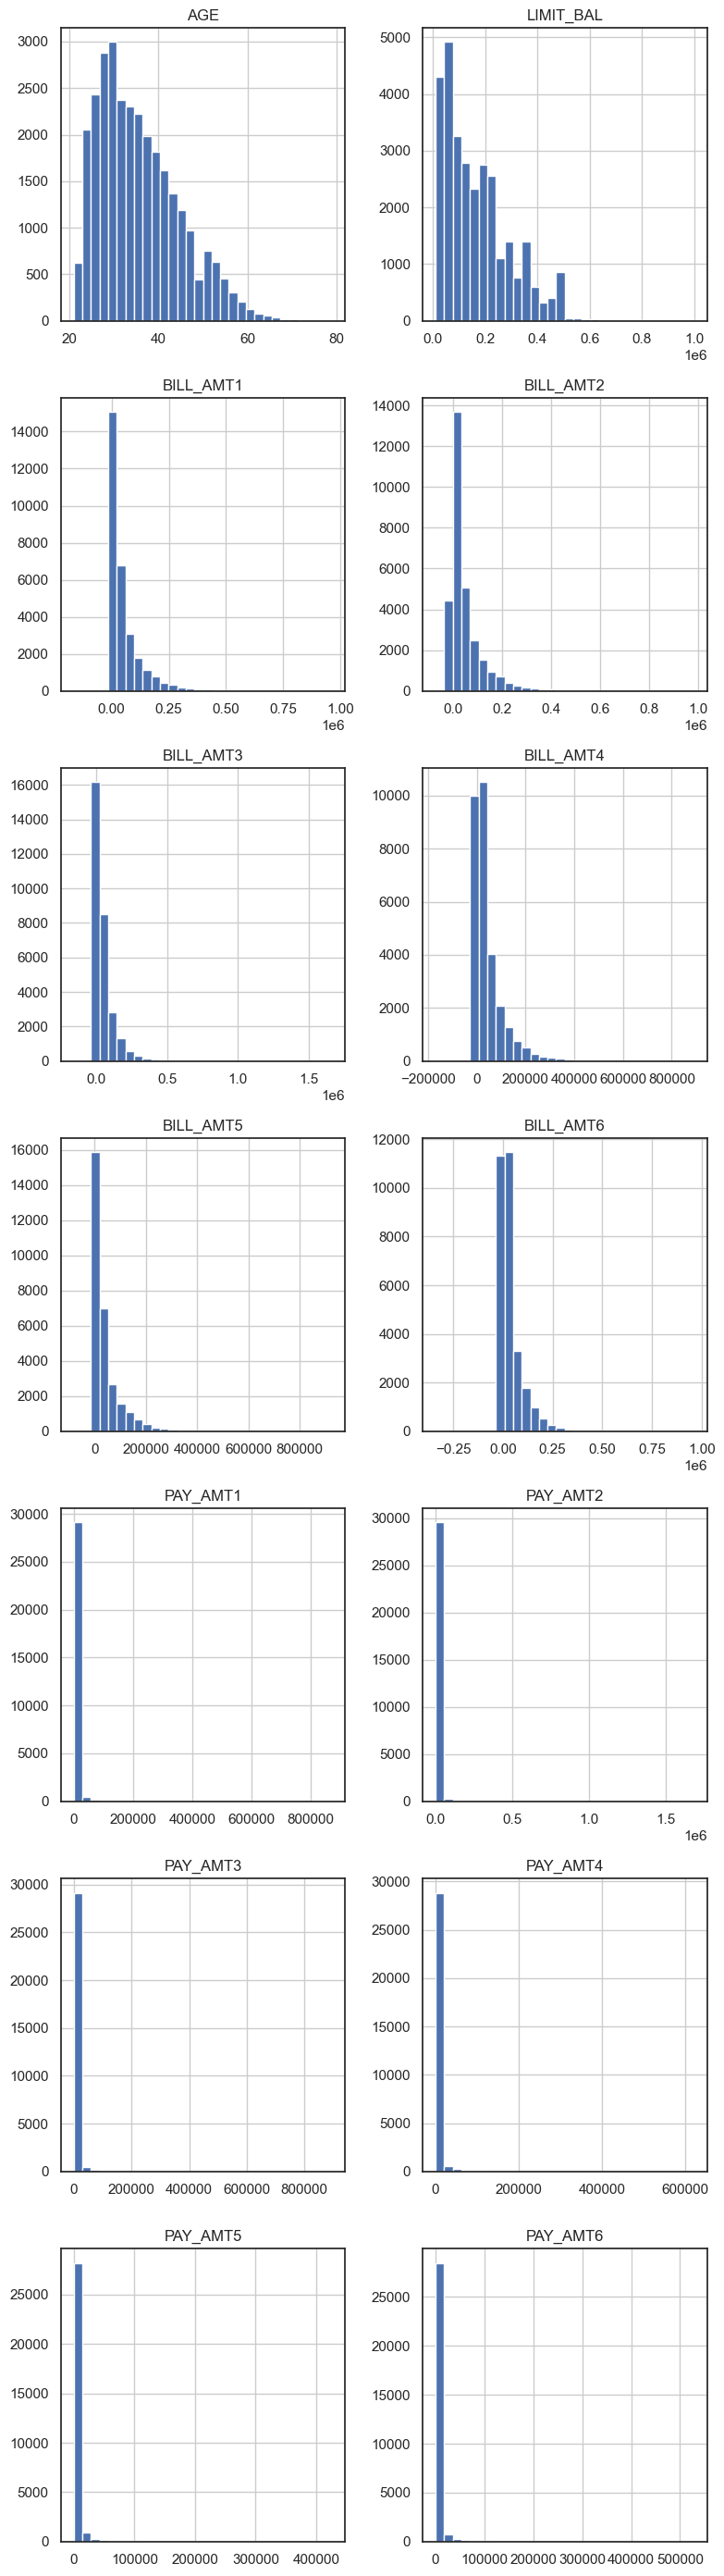

In [12]:
fig, axes = plt.subplots(7, 2, figsize=(8, 28))
for ax, col in zip(axes.flatten(), con_features):
    df[col].hist(ax=ax, bins=30)
    ax.set_title(col)
for ax in axes.flatten()[len(con_features):]:
    ax.axis('off')
plt.tight_layout()
plt.show()

# 4. Bivariate Analysis

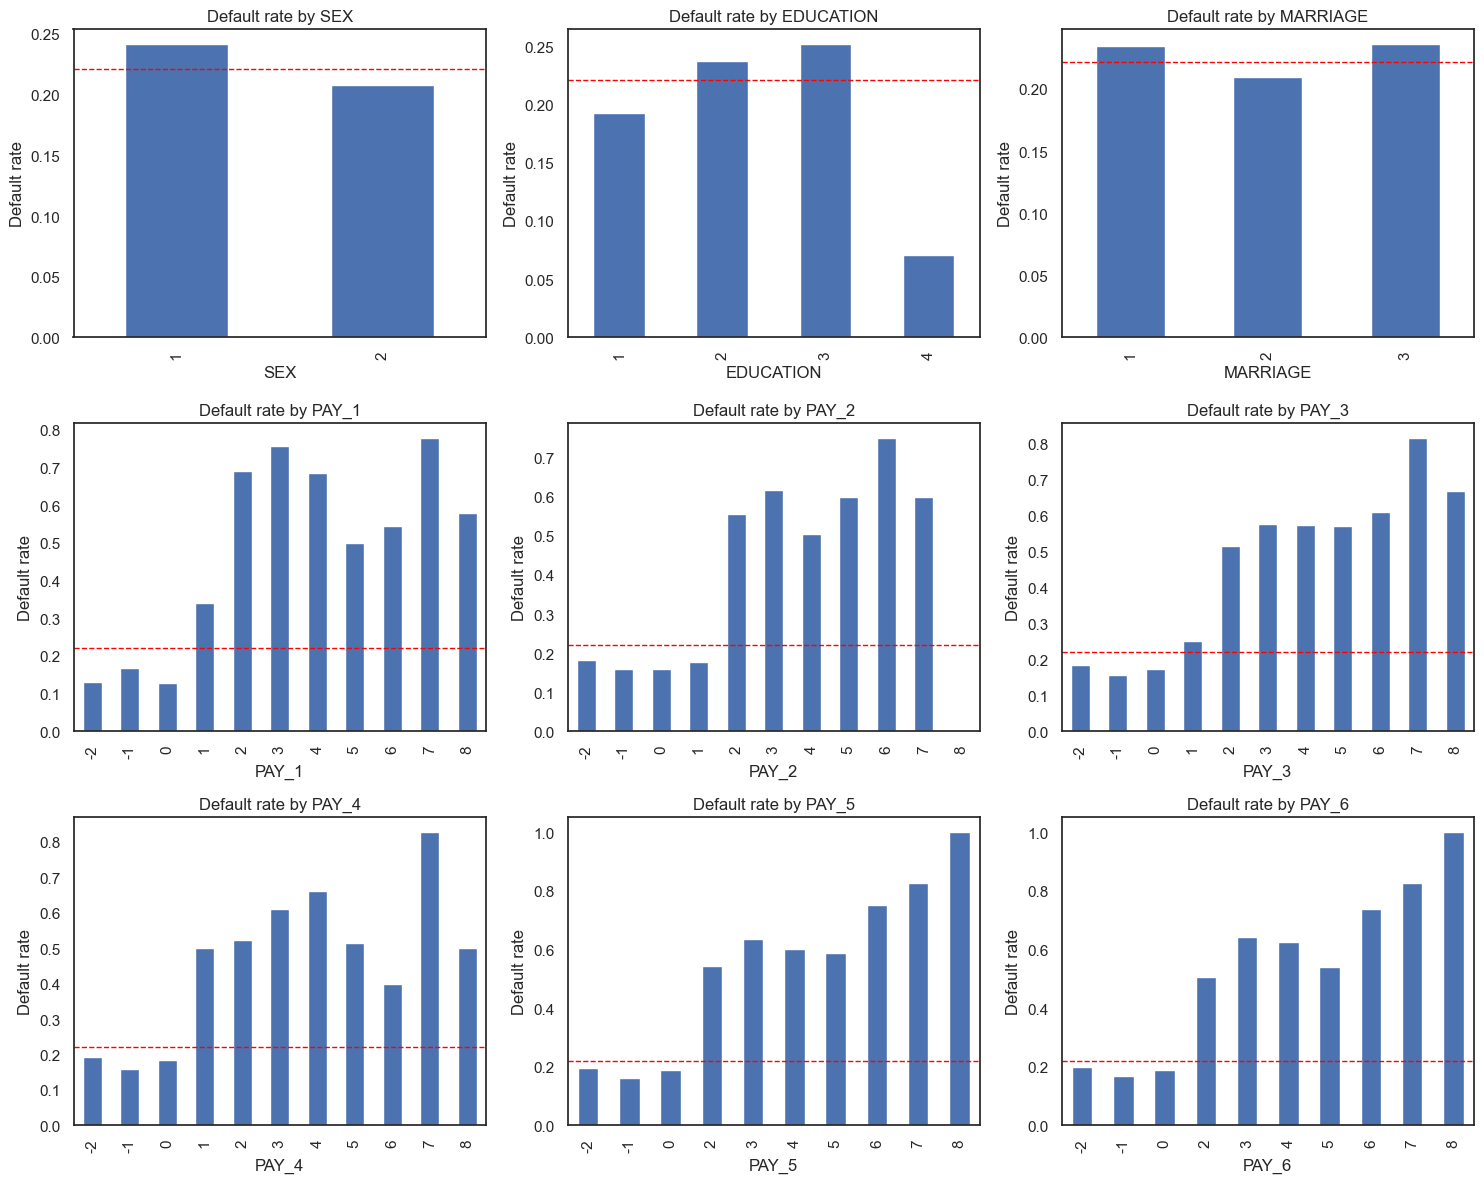

In [13]:
overall_rate = df[target].mean()

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for ax, col in zip(axes.flatten(), cat_features):
    rate = df.groupby(col)[target].mean().sort_index()
    rate.plot.bar(ax=ax, title=f'Default rate by {col}')
    ax.axhline(overall_rate, color='red', linestyle='--', linewidth=1)
    ax.set_ylabel('Default rate')
plt.tight_layout()
plt.show()

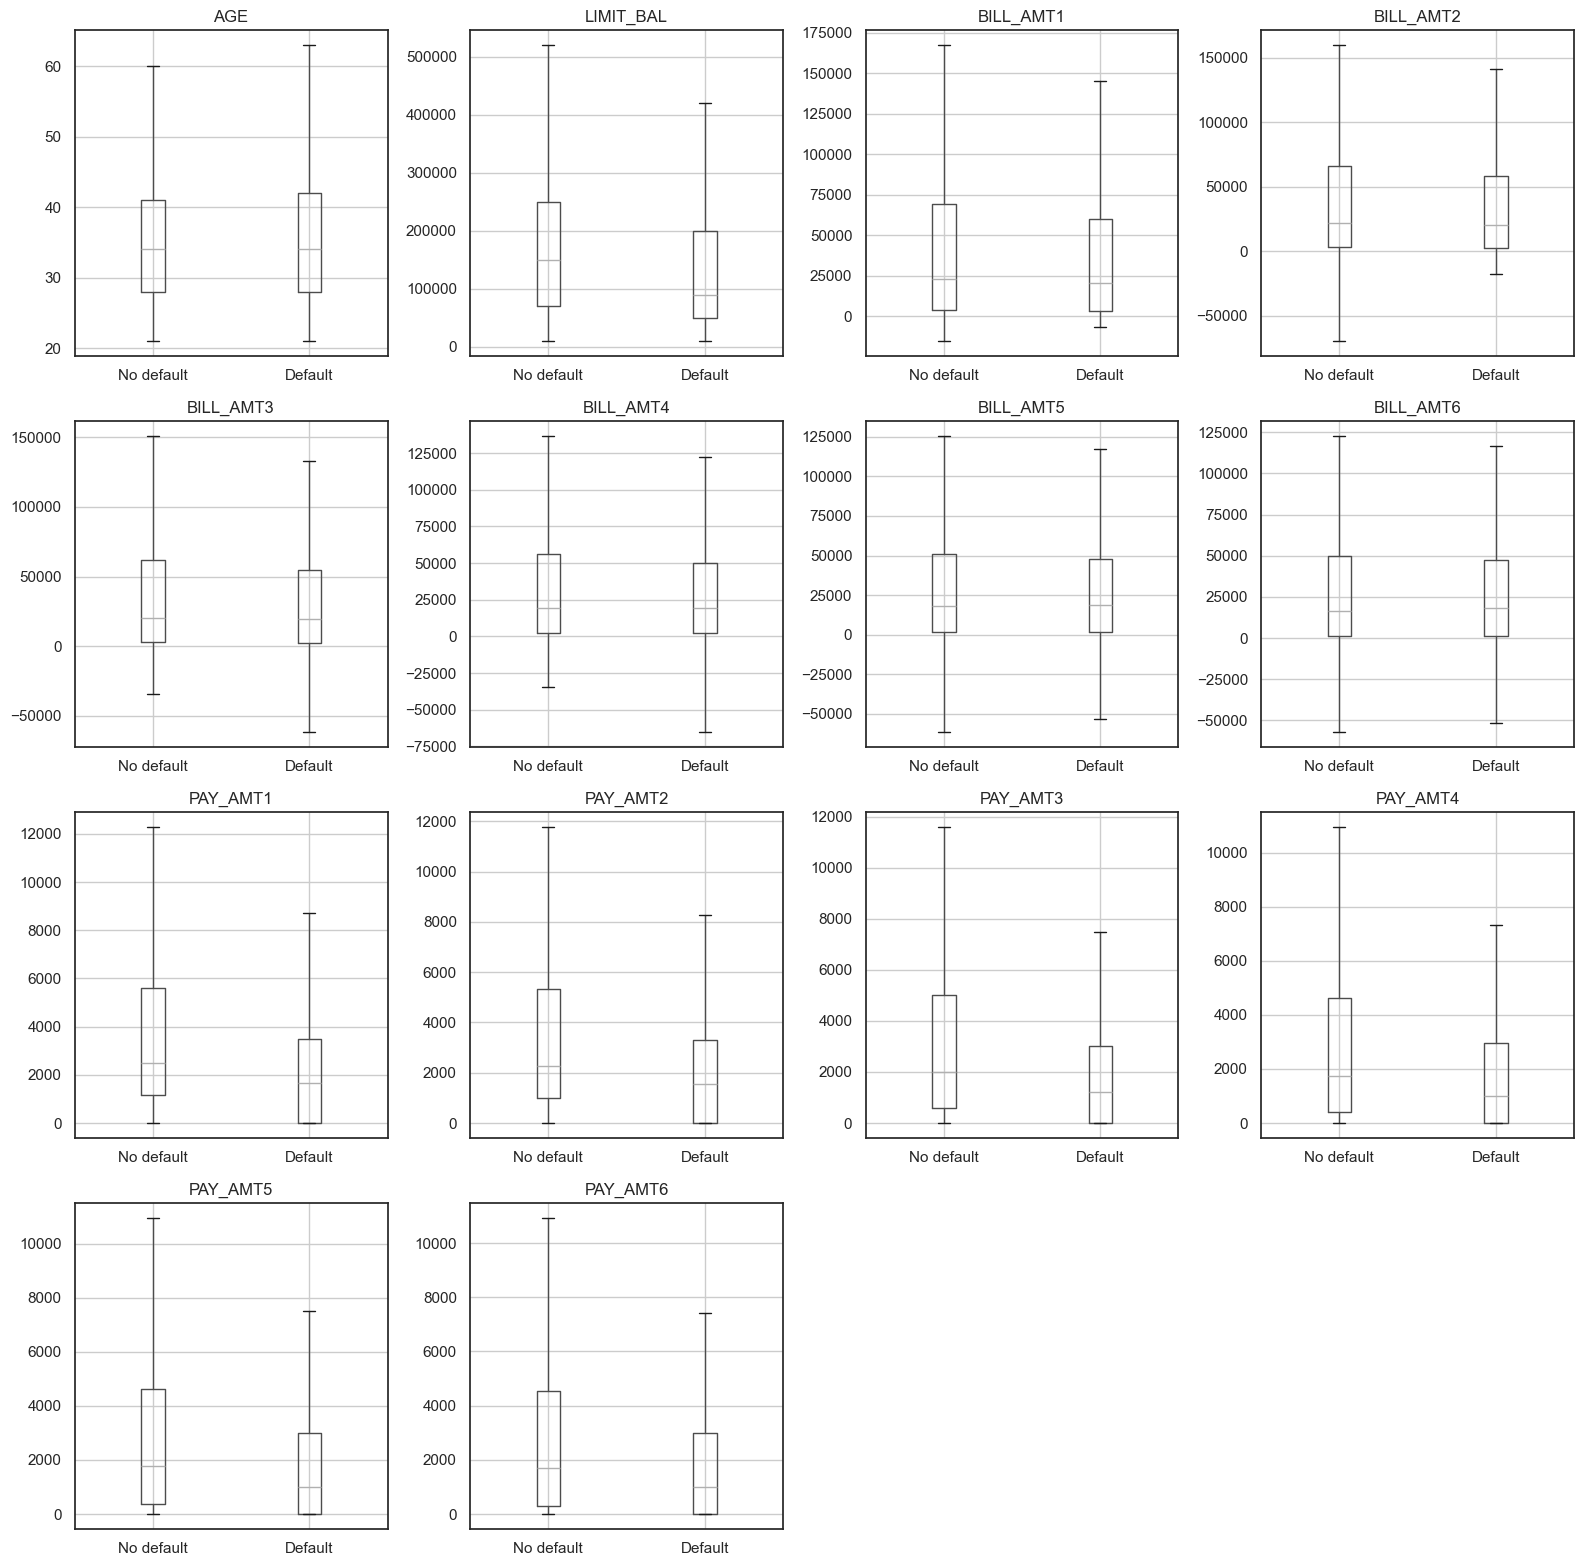

In [14]:
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
for ax, col in zip(axes.flatten(), con_features):
    df.boxplot(column=col, by=target, ax=ax, showfliers=False)
    ax.set_xticklabels(['No default', 'Default'])
    ax.set_title(col)
    ax.set_xlabel('')
for ax in axes.flatten()[len(con_features):]:
    ax.axis('off')
plt.suptitle('')
plt.tight_layout()
plt.show()